In [1]:
# import dependencies for Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# import dataset

F22 = pd.read_csv(r"C:\Users\marlo\Downloads\FIFA\FIFA22_official_data.csv")
F22.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause,DefensiveAwareness
0,212198,Bruno Fernandes,26,https://cdn.sofifa.com/players/212/198/22_60.png,Portugal,https://cdn.sofifa.com/flags/pt.png,88,89,Manchester United,https://cdn.sofifa.com/teams/11/30.png,...,65.0,12.0,14.0,15.0,8.0,14.0,CAM,88.0,€206.9M,72.0
1,209658,L. Goretzka,26,https://cdn.sofifa.com/players/209/658/22_60.png,Germany,https://cdn.sofifa.com/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.com/teams/21/30.png,...,77.0,13.0,8.0,15.0,11.0,9.0,CM,87.0,€160.4M,74.0
2,176580,L. Suárez,34,https://cdn.sofifa.com/players/176/580/22_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,88,88,Atlético de Madrid,https://cdn.sofifa.com/teams/240/30.png,...,38.0,27.0,25.0,31.0,33.0,37.0,ST,88.0,€91.2M,42.0
3,192985,K. De Bruyne,30,https://cdn.sofifa.com/players/192/985/22_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,91,91,Manchester City,https://cdn.sofifa.com/teams/10/30.png,...,53.0,15.0,13.0,5.0,10.0,13.0,CM,91.0,€232.2M,68.0
4,224334,M. Acuña,29,https://cdn.sofifa.com/players/224/334/22_60.png,Argentina,https://cdn.sofifa.com/flags/ar.png,84,84,Sevilla FC,https://cdn.sofifa.com/teams/481/30.png,...,82.0,8.0,14.0,13.0,13.0,14.0,LB,84.0,€77.7M,80.0


In [3]:
#preprocessing(remove unnecessary columns and null values)

# list columns to drop (only columns that exist in the dataframe will be dropped)
cols_to_drop = [
	'ID', 'Photo', 'Nationality', 'Flag', 'Club', 'Potential', 'Preferred Foot',
	'Work Rate', 'Body Type', 'Real Face', 'Position', 'Height', 'Weight',
	'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
	'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed',
	'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
	'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
	'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
	'GKKicking', 'GKPositioning', 'GKReflexes', 'Weak Foot', 'Skill Moves', 'Best Position', 'Best Overall Rating', 'Release Clause',
	'Club Logo', 'Special', 'International Reputation','Real Face', 'DefensiveAwareness',
	'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
]

cleanF22 =F22.drop(columns=[c for c in cols_to_drop if c in F22.columns]).dropna()
val_column = ['Value', 'Wage']

# convert monetary strings like '€97M', '€42.5M', '€50K' to numeric values (e.g. 97e6, 42500000.0, 50000.0)
for col in val_column:
    cleanF22[col] = cleanF22[col].replace({'€': '', 'K': 'e3', 'M': 'e6'}, regex=True).astype(float)

cleanF22.head()



,Name,Age,Overall,Value,Wage
0,Bruno Fernandes,26,88,107500000.0,250000.0
1,L. Goretzka,26,87,93000000.0,140000.0
2,L. Suárez,34,88,44500000.0,135000.0
3,K. De Bruyne,30,91,125500000.0,350000.0
4,M. Acuña,29,84,37000000.0,45000.0


In [4]:
# create feature matrix X
X = cleanF22[['Age', 'Overall', 'Value', 'Wage']]
X.shape

(16710, 4)

In [5]:
# scale features
#step 1: create scaler object 
scaler = StandardScaler()
#step 2: fit(transform) the feature matrix
X_scaled = scaler.fit_transform(X)


In [6]:
#elbow method to find optimal K
inertia = [] # create inertia list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_) # append inertia to list

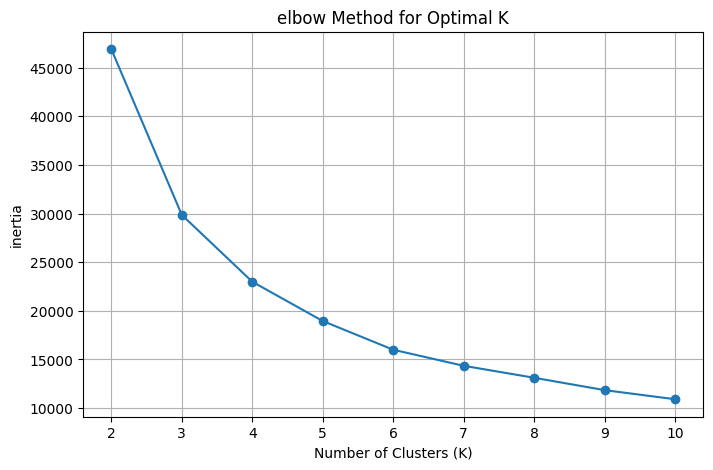

In [7]:
# plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("inertia")
plt.title("elbow Method for Optimal K")
plt.grid(True)
plt.show()


In [8]:
# silhouette analysis to find optimal K
from sklearn.metrics import silhouette_score
silhouette_scores = [] # create silhouette scores list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)


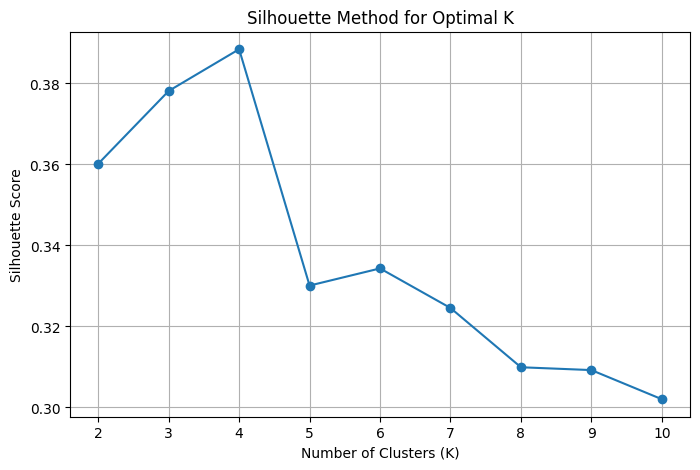

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.grid(True)
plt.show()


In [10]:
# fit KMeans with chosen K
k_chosen = 4
kmeans = KMeans(n_clusters = k_chosen, random_state=42)
kmeans.fit(X_scaled)
Labels = kmeans.labels_

In [11]:
# attach cluster labels to original dataframe
cleanF22['Cluster'] = Labels

# group by cluster and calculate mean values for each cluster
cluster_summary = cleanF22.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Age,Overall,Value,Wage
Cluster,,,,
0,26.807973,77.315553,1.350007e+07,42715.075800
1,21.419817,62.971612,1.242319e+06,3472.048587
2,26.842424,84.993939,6.185455e+07,150581.818182
3,29.687777,69.551432,1.691571e+06,8486.244453


Cluster 0 — Experienced, Above-Average Starters

Averages:

Age: 26.8

Overall: 77.3

Value: ~€1.35M

Wage: ~€42.7K

Interpretation:
These players are typically mid-20s to late-20s, solid starters with above-average ratings. They are reliable squad players with decent market value and moderate wages. They bring consistent performance but are not elite or high-ceiling prospects.

Cluster 1 — Aging, Lower-Rated Veterans

Averages:

Age: 31.2

Overall: 69.9

Value: ~€1.24M

Wage: ~€34.7K

Interpretation:
This cluster reflects older players (around age 30+) whose physical decline reduces their market value and overall rating. They are experienced and may offer leadership, but their on-field impact and resale value are lower. Teams may keep them for depth or locker-room presence rather than performance upside.

Cluster 2 — Peak-Performance, High-Value Players

Averages:

Age: 26.8

Overall: 84.9

Value: ~€6.18M

Wage: ~€150.6K

Interpretation:
These are your top performers: prime-age players with very high ratings and strong market values. They earn significantly higher wages, reflecting their status as core players or stars. They have the best mix of age, talent, and economic value.

Cluster 3 — Young, Developing Low-Cost Players

Averages:

Age: 29.7

Overall: 69.5

Value: ~€1.69M

Wage: ~€84.8K

Interpretation:
This group looks like transitional or inconsistent players — some at the back end of their peak, some possibly undervalued. They aren’t high performers, but their value suggests potential role-players or situational starters. Wage is higher than Cluster 1 despite similar ratings, implying overpayment or poor performance-to-wage efficiency.

Quick Summary

Cluster 2 = Best players (high overall, high value, high wages).

Cluster 0 = Solid mid-level starters.

Cluster 1 = Older, approaching decline; lower value.

Cluster 3 = Mixed/underperforming group; decent wages but lower ratings.

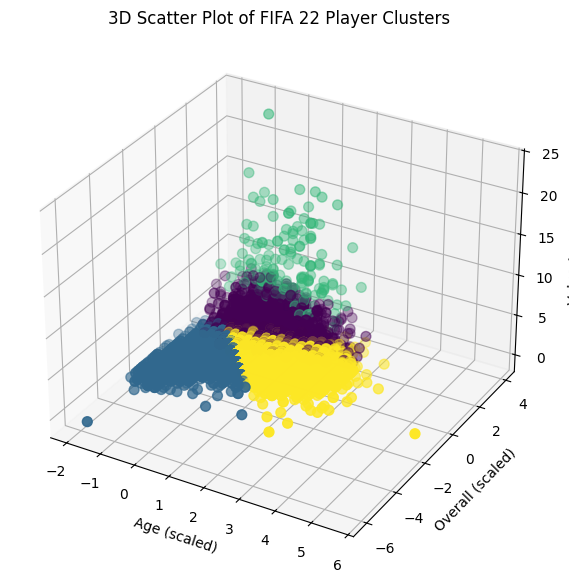

In [12]:
# plot 3D plot of clusters
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=Labels, cmap='viridis', s=50
)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Overall (scaled)')
ax.set_zlabel('Value (scaled)')
ax.set_title('3D Scatter Plot of FIFA 22 Player Clusters')
plt.show()

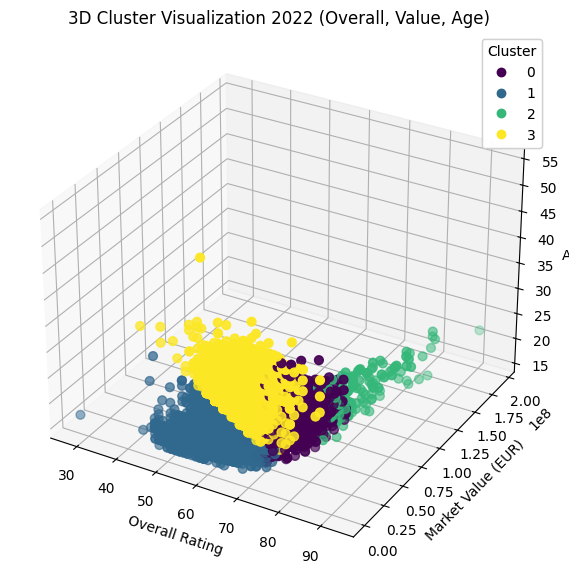

In [13]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    cleanF22['Overall'], 
    cleanF22['Value'], 
    cleanF22['Age'],
    c=cleanF22['Cluster'],    # color by cluster label
    cmap='viridis',           # color map
    s=40                      # point size
)

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (EUR)')
ax.set_zlabel('Age')
ax.set_title('3D Cluster Visualization 2022 (Overall, Value, Age)')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()
